In [44]:
import torch
import cv2
from facenet_pytorch import MTCNN
import IPython
from tqdm import tqdm

In [90]:
def draw_faces(image, faces, threshold=0.5):
    for face in faces[0]:
        if face[-1] > threshold:
            x1, y1, x2, y2 = [int(x) for x in face.tolist()]
            color = (0, 0, 255)
            thickness = 2
            cv2.rectangle(image, (x1, y1), (x2, y2), color, thickness, cv2.LINE_AA)

In [4]:
def show_image(image):
    _, ret = cv2.imencode('.jpg', image)
    i = IPython.display.Image(data=ret)
    IPython.display.display(i)

In [5]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('Running on device: {}'.format(device))

Running on device: cuda:0


In [22]:
mtcnn = MTCNN(keep_all=True, device=device)

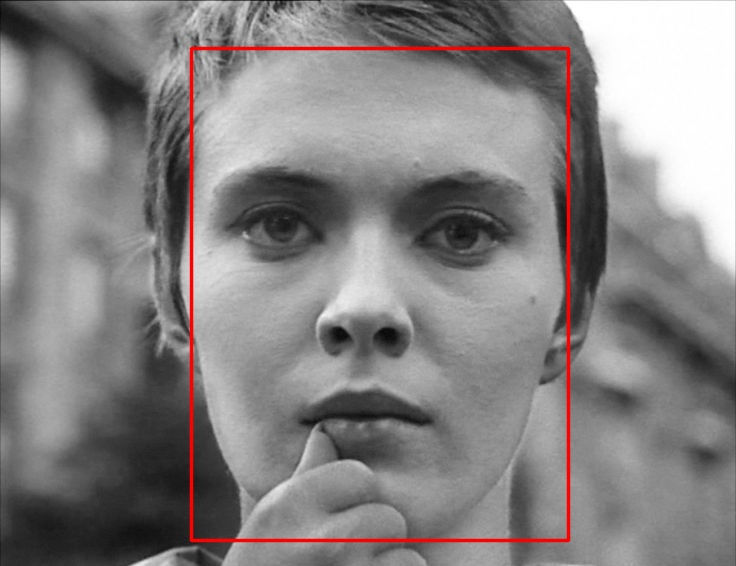

In [18]:
img = cv2.imread('./images/img_1.jpg')
faces = mtcnn.detect(img)
draw_faces(img, faces)
show_image(img)

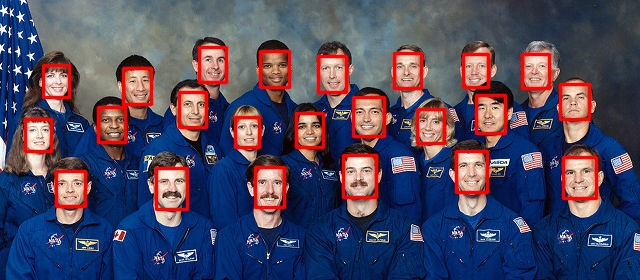

In [19]:
img = cv2.imread('./images/img_2.jpg')
faces = mtcnn.detect(img)
draw_faces(img, faces)
show_image(img)

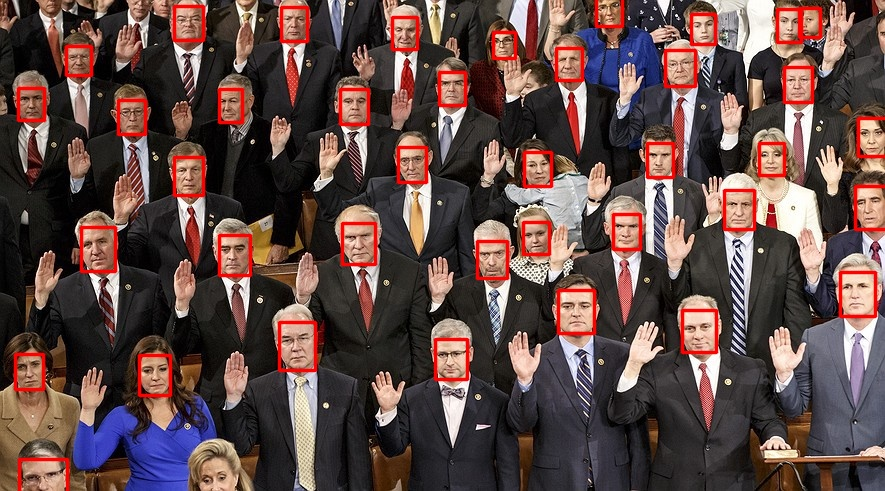

In [96]:
img = cv2.imread('./images/img_3.jpg')
faces = mtcnn.detect(img)
draw_faces(img, faces, threshold=0.9)
show_image(img)

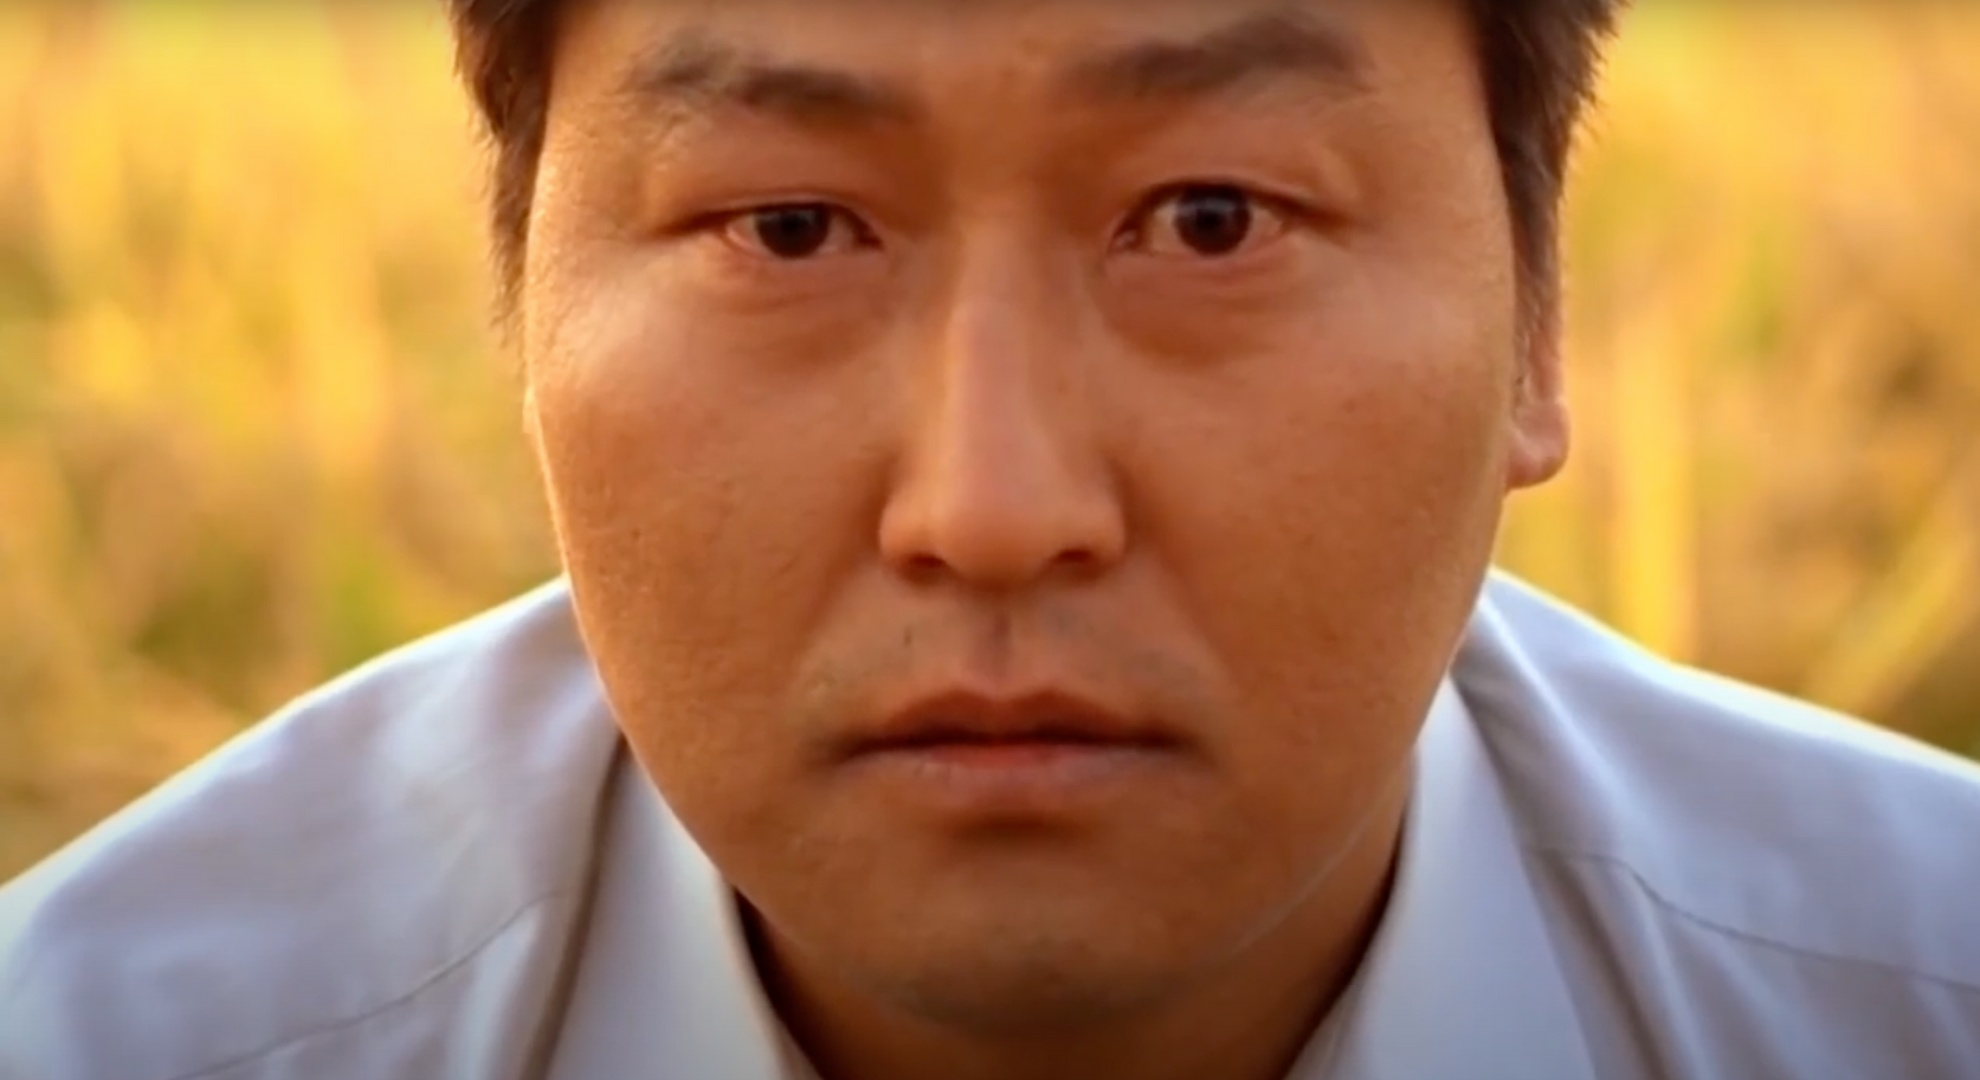

In [30]:
img = cv2.imread('./images/img_4.jpg')
faces = mtcnn.detect(img)
if any(faces):
    draw_faces(img, faces)
show_image(img)

In [89]:
img = cv2.imread('./images/img_5.jpg')
faces = mtcnn.detect(img, confidence_threshold=0.5)
if faces[0]:
    draw_faces(img, faces)
show_image(img)

TypeError: MTCNN.detect() got an unexpected keyword argument 'confidence_threshold'

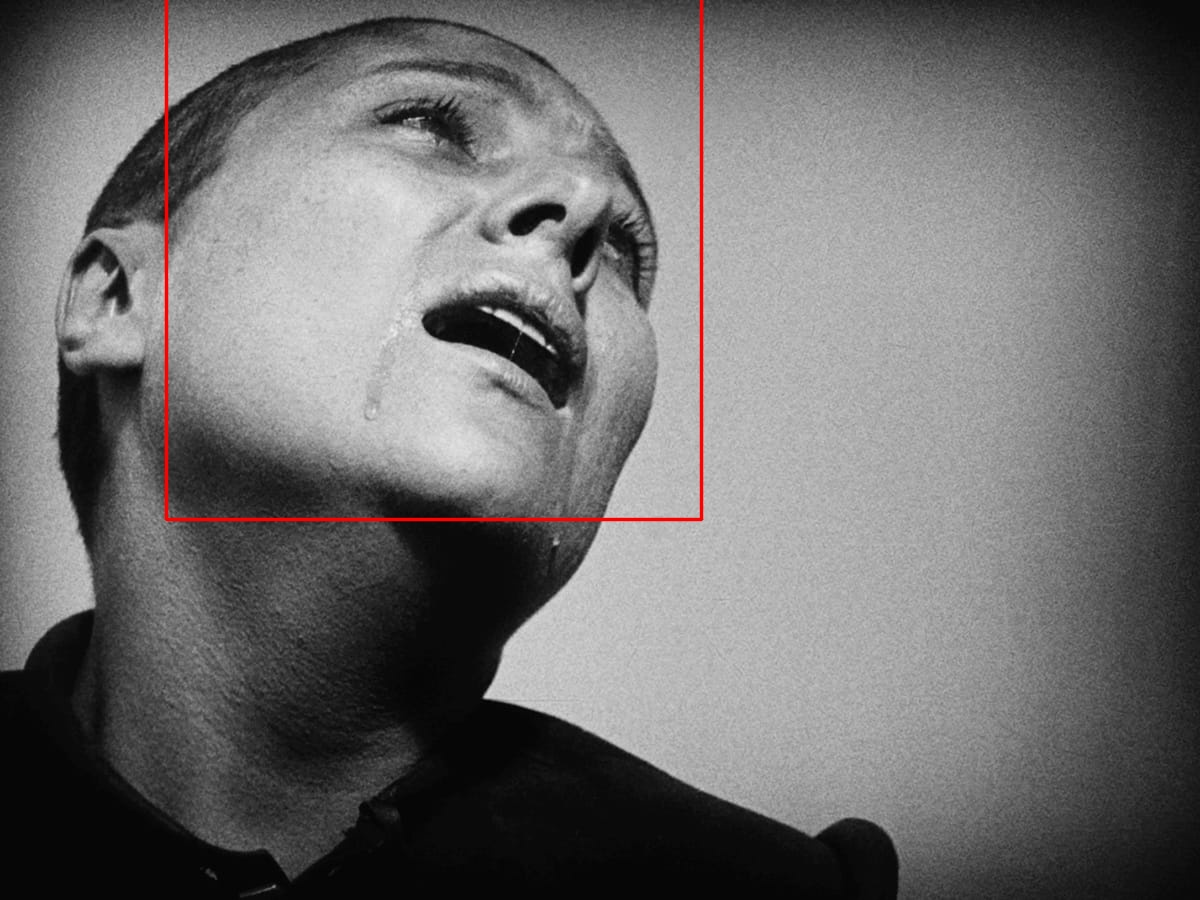

In [71]:
img = cv2.imread('./images/img_6.jpg')
faces = mtcnn.detect(img)
if faces[0] is not None:
    draw_faces(img, faces)
show_image(img)

In [72]:
len(faces)

2

In [92]:
cap = cv2.VideoCapture('./data/test.mkv')

  0%|          | 384/111290 [00:05<25:31, 72.41it/s] 


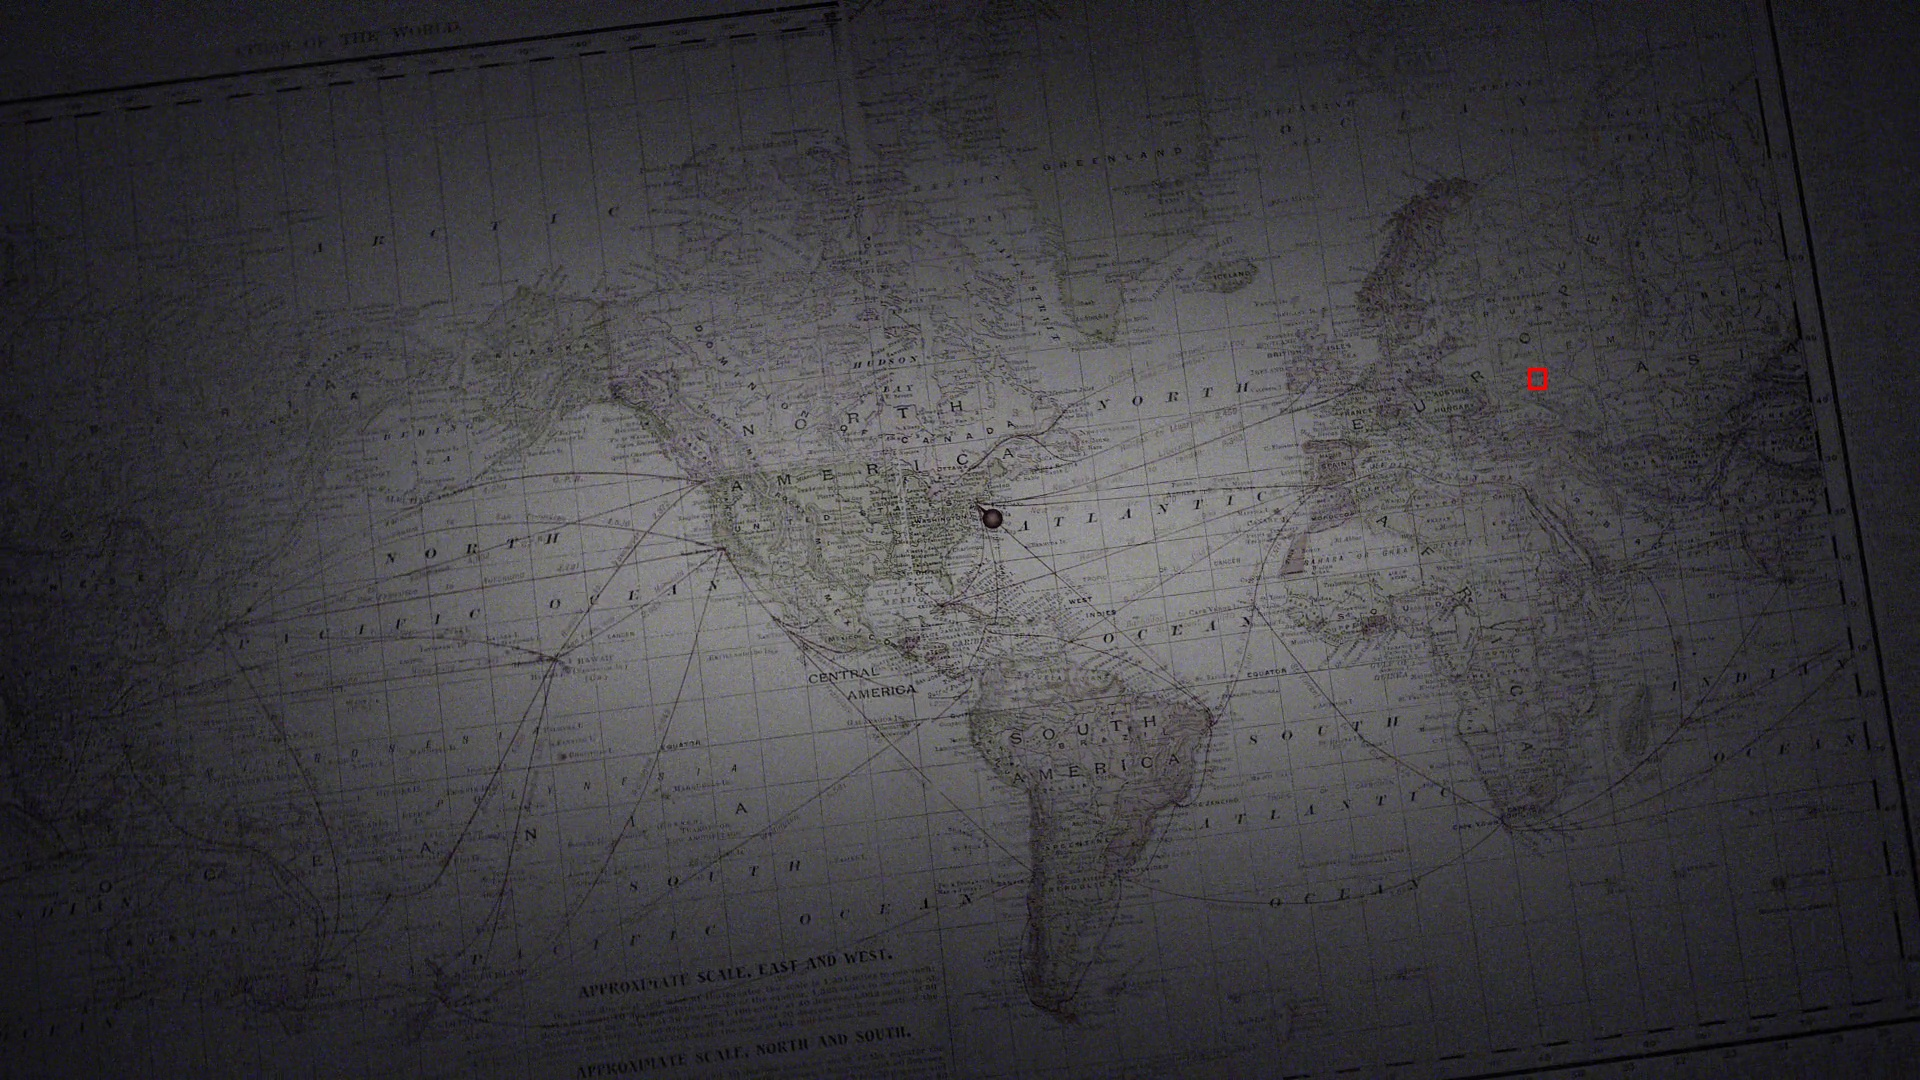

24 [0.9181597828865051]


In [94]:
cnt = 0
_, _ = cap.read()
framecount = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
pb = tqdm(total=framecount)
while True:
    if cnt % 24 == 0:
        _, frame = cap.read()
        img = frame
        # img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        faces = mtcnn.detect(img)
        if faces[0] is None:
            pb.update(1)
            cnt += 1
            continue
        draw_faces(img, faces, threshold=0.95)
        show_image(img)
        break
    cnt = cnt + 1
    pb.update(1)
print(cnt, faces[1])

In [59]:
faces[1].shape

(1,)

In [55]:
type(faces)[1]

tuple[1]

In [68]:
if not any(faces[0]):
    print('t')

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [69]:
len(faces)

2

In [83]:
img = cv2.imread('./images/img_3.jpg')
faces = mtcnn(img)
faces

tensor([[[[-0.3086, -0.3086, -0.3086,  ..., -0.8242, -0.8242, -0.8242],
          [-0.3086, -0.3086, -0.3086,  ..., -0.8242, -0.8242, -0.8242],
          [-0.3086, -0.3086, -0.3086,  ..., -0.8242, -0.8242, -0.8242],
          ...,
          [-0.3711, -0.3711, -0.3711,  ..., -0.8164, -0.8164, -0.8164],
          [-0.3711, -0.3711, -0.3711,  ..., -0.8164, -0.8164, -0.8164],
          [-0.3711, -0.3711, -0.3711,  ..., -0.8164, -0.8164, -0.8164]],

         [[-0.1523, -0.1523, -0.1523,  ..., -0.7383, -0.7383, -0.7383],
          [-0.1523, -0.1523, -0.1523,  ..., -0.7383, -0.7383, -0.7383],
          [-0.1523, -0.1523, -0.1523,  ..., -0.7383, -0.7383, -0.7383],
          ...,
          [-0.1211, -0.1211, -0.1211,  ..., -0.6445, -0.6445, -0.6445],
          [-0.1211, -0.1211, -0.1211,  ..., -0.6445, -0.6445, -0.6445],
          [-0.1211, -0.1211, -0.1211,  ..., -0.6445, -0.6445, -0.6445]],

         [[-0.0117, -0.0117, -0.0117,  ..., -0.6289, -0.6289, -0.6289],
          [-0.0117, -0.0117, -

In [87]:
faces.shape

torch.Size([39, 3, 160, 160])